# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [1]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [6]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])
data.describe()

,survived,pclass,age,sibsp,parch,fare,sex_label
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.647587
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.477990
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [7]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')
data.describe()

,survived,pclass,age,sibsp,parch,fare,sex_label
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.647587
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.477990
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


In [8]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

In [ ]:
LabelEncoder es suficiente para sex porque es binario.
OneHotEncoder es mejor para embarked porque tiene más de dos categorías y evita relaciones falsas entre clases.



### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

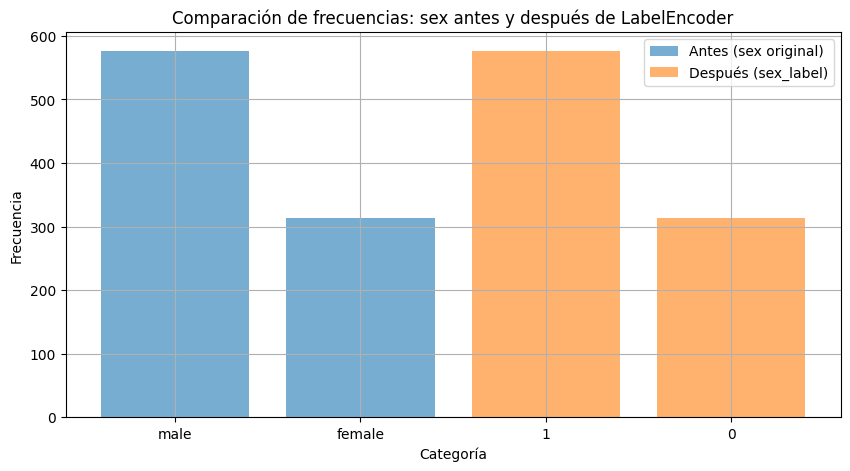

In [9]:
import matplotlib.pyplot as plt

# Frecuencias antes de la codificación
sex_original = data['sex'].value_counts()

# Frecuencias después de LabelEncoder
sex_encoded = data['sex_label'].value_counts()

plt.figure(figsize=(10,5))

# Antes
plt.bar(sex_original.index.astype(str), sex_original.values, alpha=0.6, label="Antes (sex original)")

# Después
plt.bar(sex_encoded.index.astype(str), sex_encoded.values, alpha=0.6, label="Después (sex_label)")

plt.title("Comparación de frecuencias: sex antes y después de LabelEncoder")
plt.xlabel("Categoría")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True)
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [12]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False)

class_encoded = encoder.fit_transform(data[['class']])

# Convertir a DataFrame con nombres de columnas
class_encoded_df = pd.DataFrame(
    class_encoded,
    columns=encoder.get_feature_names_out(['class'])
)

# Unir al dataset original
data = pd.concat([data, class_encoded_df], axis=1)
data.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,embarked_S,class_First,class_Second,class_Third,class_First,class_Second,class_Third,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,False,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,True,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

In [ ]:
OneHotEncoder No introduce orden artificial
Evita que el modelo interprete relaciones falsas (ej. “Third > First”)
Funciona bien con la mayoría de modelos (regresión logística, SVM, redes neuronales, etc.)